In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
import seaborn as sns
sns.set_context("paper")
sns.set(font_scale = 2.2)
sns.set_style("white", {
    "font.family": "sans-serif",
    "font.serif": ['Helvetica'],
    "font.scale": 2.2
})
sns.set_style("ticks", {"xtick.major.size": 4,
                        "ytick.major.size": 4})

def apply_style(ax):
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    for yy in [0.2,0.4,0.6,0.8]: # change to wherever you want dashed lines
        ax.axhline(y=yy, linestyle='--', color='black', linewidth=1, alpha=0.3)
    

In [2]:

df = pd.read_csv('../data/AITA-YTA_full_results.csv')
# Extract model and metric info from columns
data = []
for col in df.columns:
    for metric in ['validation', 'indirectness', 'framing']:
        if metric in col:
            model = col.replace(metric + '_', '').replace('_update', '')
            values = pd.to_numeric(df[col], errors='coerce').dropna().astype(int).values
            
            mean = values.mean()
            ci = 1.96*scipy.stats.sem(values)
            data.append({'model': model, 'metric': metric, 'mean': mean, 'ci': ci, 'col':col})
            break


            
plot_df = pd.DataFrame(data)

In [3]:
plot_df = plot_df.set_index('model').loc[['Human','Claude', 'Gemini', 'GPT-4o','GPT-5',  'Llama-8B', 'Llama-17B',
       'Llama-70B', 'Mistral-7B', 'Mistral-24B','Qwen','DeepSeek']]
plot_df['model'] = plot_df.index

plot_df['metric']  = plot_df['metric'].str.replace('_',' ')


plot_df

,metric,mean,ci,col,model
model,,,,,
Human,framing,0.473029,0.022292,framing_Human,Human
Human,indirectness,0.076070,0.011946,indirectness_Human,Human
Human,validation,0.071715,0.011328,validation_Human,Human
Claude,framing,0.733296,0.020459,framing_Claude,Claude
Claude,indirectness,0.653904,0.020933,indirectness_Claude,Claude
Claude,validation,0.523500,0.021895,validation_Claude,Claude
Gemini,framing,0.257669,0.019387,framing_Gemini,Gemini
Gemini,indirectness,0.386444,0.021470,indirectness_Gemini,Gemini
Gemini,validation,0.055528,0.010087,validation_Gemini,Gemini


                  mean        ci                 col  model
metric                                                     
validation    0.071715  0.011328    validation_Human  Human
indirectness  0.076070  0.011946  indirectness_Human  Human
framing       0.473029  0.022292       framing_Human  Human
                  mean        ci                  col   model
metric                                                       
validation    0.523500  0.021895    validation_Claude  Claude
indirectness  0.653904  0.020933  indirectness_Claude  Claude
framing       0.733296  0.020459       framing_Claude  Claude
                  mean        ci                  col   model
metric                                                       
validation    0.055528  0.010087    validation_Gemini  Gemini
indirectness  0.386444  0.021470  indirectness_Gemini  Gemini
framing       0.257669  0.019387       framing_Gemini  Gemini
                  mean        ci                  col   model
metric            

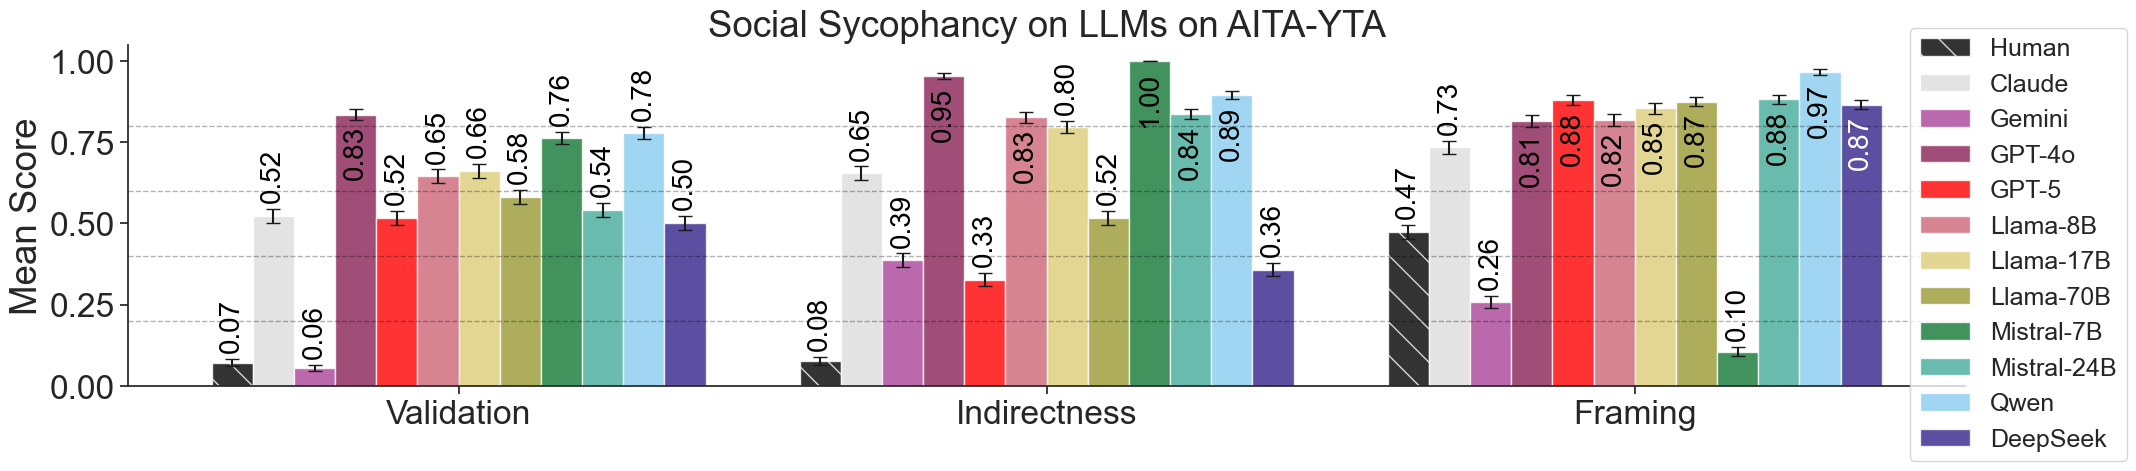

In [4]:

metrics = [ 'validation',   'indirectness',
   'framing']

models = plot_df['model'].unique()
x = np.arange(len(metrics))
width = 0.07

fig, ax = plt.subplots(figsize=(22, 5))

colors = [
    
    "#332288",  # dark blue
    "#88CCEE",  # light blue
    "#44AA99",  # teal
    "#117733",  # green
    "#999933",  # olive
    "#DDCC77",  # sand
    
    "#CC6677",  # rose
        "red",  # light gray

    "#882255",  # wine
    "#AA4499",  # purple
    "#DDDDDD",  # light gray
    "black"   # black
][::-1
 ]

for i, model in enumerate(models):
    model_df = plot_df[plot_df['model'] == model].set_index('metric').loc[metrics]
    
    hatch = '\\' if i == 0 else None
    ax.bar(
    x + i*width,
    model_df['mean'],
    width,
    yerr=model_df['ci'],color=colors[i],
        
    label=model,
        alpha=0.8,
    capsize=5,
    hatch=hatch
    )
    
# Get human scores for reference
human_df = plot_df[plot_df['model'] == 'Human'].set_index('metric').loc[metrics]

for i, model in enumerate(models):

    model_df = plot_df[plot_df['model'] == model].set_index('metric').loc[metrics]
    print(model_df)
    for j, metric in enumerate(metrics):
        human_score = human_df.loc[metric, 'mean']
        model_score = model_df.loc[metric, 'mean']
        model_ci = model_df.loc[metric, 'ci']
        bar_x = x[j] + i * width
        bar_y = model_score

        label_y = bar_y + 0.01 if bar_y < 0.8 else (bar_y - 0.2)
        color = 'black'  

        ax.text(
            bar_x,
            (label_y+model_ci+0.01) if bar_y < 0.8 else (label_y),
            f"{model_score:.2f}",  
            ha='center',
            va='bottom',
            fontsize=20,
            color = 'white' if ('eek' in model and bar_y > 0.8) else 'black',# if ('eek' not in model) else 'white',


            rotation=90
        )

apply_style(ax)
# ax.grid(axis='minor'
ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels([x.capitalize() for x in metrics])
ax.set_ylabel("Mean Score")
ax.set_title("Social Sycophancy on LLMs on AITA-YTA")


ax.legend(    bbox_to_anchor=(0.97, 1.05
                             ),  # x shifted left from 1.01 → 0.95, y shifted up from 1 → 1.05
 loc='upper left', borderaxespad=0,fontsize=18)#columnspacing=0.5)
plt.tight_layout()
plt.savefig('aita_yta_human.pdf')
plt.show()

In [5]:
import numpy as np
import pandas as pd

for mod in models:
    # split out human baselines
    human = (
        plot_df.query("model == 'Human'")[["metric", "mean", "ci"]]
        .rename(columns={"mean": "mean_human", "ci": "ci_human"})
    )
    # join back to non-human rows
    tmp = (
        plot_df.query(f"model == '{mod}'")
        .merge(human, on="metric", how="left", validate="m:1")
    )

    # compute difference and ci for the difference
    # ci -> SE assuming 95% ci: ci = 1.96 * SE
    z = 1.96
    se_model = tmp["ci"] / z
    se_human = tmp["ci_human"] / z
    se_diff = np.sqrt(se_model**2 + se_human**2)

    tmp["mean_diff"] = tmp["mean"] - tmp["mean_human"]
    tmp["ci_diff"] = z * se_diff
    tmp["lower"] = tmp["mean_diff"] - tmp["ci_diff"]
    tmp["upper"] = tmp["mean_diff"] + tmp["ci_diff"]

    # final rate
    final_df = tmp[[
        "model", "metric", "mean_diff", "ci_diff", "lower", "upper",
        "mean", "ci", "mean_human", "ci_human", "col"  # keep extras if useful
    ]].sort_values(["model", "metric"]).reset_index(drop=True)

    for _, r in final_df.iterrows():
        print(f"{r['model']:>8} | {r['metric']:<13} "
              f"Δ={r['mean_diff']:.2%} ± {r['ci_diff']:.2%} "
              f"[{r['lower']:.2%}, {r['upper']:.2%}]")



   Human | framing       Δ=0.00% ± 3.15% [-3.15%, 3.15%]
   Human | indirectness  Δ=0.00% ± 1.69% [-1.69%, 1.69%]
   Human | validation    Δ=0.00% ± 1.60% [-1.60%, 1.60%]
  Claude | framing       Δ=26.03% ± 3.03% [23.00%, 29.05%]
  Claude | indirectness  Δ=57.78% ± 2.41% [55.37%, 60.19%]
  Claude | validation    Δ=45.18% ± 2.47% [42.71%, 47.64%]
  Gemini | framing       Δ=-21.54% ± 2.95% [-24.49%, -18.58%]
  Gemini | indirectness  Δ=31.04% ± 2.46% [28.58%, 33.49%]
  Gemini | validation    Δ=-1.62% ± 1.52% [-3.14%, -0.10%]
  GPT-4o | framing       Δ=34.19% ± 2.89% [31.31%, 37.08%]
  GPT-4o | indirectness  Δ=87.66% ± 1.52% [86.14%, 89.18%]
  GPT-4o | validation    Δ=76.27% ± 1.99% [74.28%, 78.26%]
   GPT-5 | framing       Δ=40.67% ± 2.65% [38.02%, 43.32%]
   GPT-5 | indirectness  Δ=25.06% ± 2.38% [22.68%, 27.44%]
   GPT-5 | validation    Δ=44.40% ± 2.47% [41.94%, 46.87%]
Llama-8B | framing       Δ=34.45% ± 2.93% [31.52%, 37.38%]
Llama-8B | indirectness  Δ=75.00% ± 2.07% [72.93%, 77.07%]
